In [1]:
import numpy as np
import time
import rasterio
import os
import requests
import shutil

from selenium import webdriver
from selenium.webdriver.common.by import By

In [2]:
save_dir = "/home/mohamed-ashraf/Desktop/projects/sat-project/data"

BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]
CLOUD_THRESHOLD = 20

mapping = {
    1: 3,  # Water → Water
    2: 4,  # Artificial Bare → Cement
    3: 2,  # Natural Bare → Sand
    5: 1,  # Woody → Greenery
    6: 1,  # Cultivated → Greenery
    7: 1   # Natural Veg → Greenery
}

In [3]:
def apply_mapping(label):
    mapped = np.zeros_like(label)
    for original, new in mapping.items():
        mapped[label == original] = new
    return mapped

In [4]:
def save_mask(input_path, save_path):
    with rasterio.open(input_path) as src:
        img = src.read()

    label = img[0]
    confidence = img[1]

    label[confidence < 80] = 0

    with rasterio.open(input_path) as src:
        profile = src.profile

    profile.update(count=1, dtype='uint8')

    mapped = apply_mapping(label)

    with rasterio.open(save_path, 'w', **profile) as dst:
        dst.write(mapped.astype('uint8'), 1)

    print("Saved mask")

In [ ]:
add = 90
counter = 0
data = ['29PNM','30PTV','30PWT','31NFH','31PGR','31PGS','32PLR','32PLS','32PPA','32PQQ','32PRQ',
        '33KUT','33KVU','33KXV','33LUC','33LUD','33LYE','33MZM','33PUQ','33PWM','35LMC','35LNF',
        '35MNT','35NLA','35NRD','35PNL','35PNR','35PRL','36MWT','36MWU','36MZT', '36NZH','36PYV',
        '36PZC','36RVP','37NCA','37NFD','37NGE','37PCM','38KMA','38NPP','38PKQ','38PKT']

while len(data) > 0:
    cr_data = data.pop()
    for i in range(30):
        i_str = f"{i:02d}"
        chip_url = f"https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/{cr_data}/{i_str}"
        raw_dir = os.path.join(save_dir, f"raw_{i_str}")
        os.makedirs(raw_dir, exist_ok=True)

        driver = webdriver.Chrome()
        driver.get(chip_url)
        time.sleep(5)

        # stop condition
        max_itr = 25
        while max_itr > 0:
            try:
                content_div = driver.find_element(
                    By.CSS_SELECTOR,
                    "div.rt-Box[style*='max-height: 800px'][style*='overflow: auto']"
                )
                break
            except Exception as e:
                if max_itr > 15:
                    print("Fail to fetch content, try again!")
                    max_itr -= 1
                    driver.refresh()
                    time.sleep(5)
                    continue
                elif max_itr > 0:
                    print(f"Max retries reached for {i_str} — stopping. with error: {e}")
                    max_itr -= 1
                    driver.refresh()
                    time.sleep(6)
                    continue
                else:
                    max_itr -= 1
                    driver.quit()
                    raise RuntimeError(f"Failed to load content for {i_str} after multiple attempts. Last error: {e}")

        # -----------------------------
        # session from selenium cookies
        # -----------------------------
        session = requests.Session()
        for cookie in driver.get_cookies():
            session.cookies.set(cookie["name"], cookie["value"])

        def download_file(url, path):
            if os.path.exists(path):
                return
            r = session.get(url, stream=True)
            r.raise_for_status()
            with open(path, "wb") as f:
                for chunk in r.iter_content(8192):
                    f.write(chunk)

        # -----------------------------
        # scroll inside product contents area
        # -----------------------------
        last_height = 0
        while True:
            driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight", content_div)
            time.sleep(1)
            new_height = driver.execute_script("return arguments[0].scrollHeight", content_div)
            current_top = driver.execute_script("return arguments[0].scrollTop", content_div)
            if new_height == last_height or current_top + 5 >= new_height - content_div.size["height"]:
                break
            last_height = new_height

        # get all links after full scroll
        links = content_div.find_elements(By.CSS_SELECTOR, "a[href]")

        if len(links) == 0:
            print(f"Empty chip {i_str}, stopping.")
            driver.quit()
            break

        date_urls = []
        mask_url = None
        mask_name = None

        for a in links:
            href = a.get_attribute("href")
            fname = a.get_attribute("download")

            if not href:
                continue

            tail = href.rstrip("/").split("/")[-1]

            if tail.startswith(f"{cr_data}_{i_str}_20") and len(tail) == len(f"{cr_data}_{i_str}_20180103"):
                date_urls.append(href.rstrip("/"))

            if fname and fname.endswith("_LC_10m.tif"):
                mask_url = href
                mask_name = fname

        date_urls = sorted(set(date_urls))
        print("Found date folders:", len(date_urls))

        if mask_url is None:
            raise RuntimeError("LC mask not found on chip page")

        # -----------------------------
        # download and save mapped mask
        # -----------------------------
        os.makedirs(os.path.join(save_dir, "masks"), exist_ok=True)
        mask_local = os.path.join(raw_dir, mask_name)
        download_file(mask_url, mask_local)
        save_mask(mask_local, os.path.join(save_dir, f"masks/mask_{i+add:02d}.tif"))

        # -----------------------------
        # process all date folders
        # -----------------------------
        all_images = []
        out_profile = None

        for date_url in date_urls:
            print("Processing:", date_url)
            driver.get(date_url)
            time.sleep(3)

            page_links = driver.find_elements(By.CSS_SELECTOR, "a[download]")

            band_files = {}
            cld_file = None

            for a in page_links:
                href = a.get_attribute("href")
                fname = a.get_attribute("download")

                if not href or not fname:
                    continue

                matched = False
                for b in BANDS:
                    if f"_{b}_10m.tif" in fname:
                        local_path = os.path.join(raw_dir, fname)
                        download_file(href, local_path)
                        band_files[b] = local_path
                        matched = True
                        break

                if matched:
                    continue

                if "_CLD_10m.tif" in fname:
                    local_path = os.path.join(raw_dir, fname)
                    download_file(href, local_path)
                    cld_file = local_path

            if len(band_files) != 12 or cld_file is None:
                print("Skipped incomplete date")
                continue

            bands_stack = []
            for b in BANDS:
                with rasterio.open(band_files[b]) as src:
                    arr = src.read(1).astype(np.float32)
                    bands_stack.append(arr)
                    if out_profile is None:
                        out_profile = src.profile.copy()

            img = np.stack(bands_stack, axis=0)

            with rasterio.open(cld_file) as src:
                cld = src.read(1)

            cloud_mask = cld >= CLOUD_THRESHOLD
            img[:, cloud_mask] = np.nan

            all_images.append(img)

        driver.quit()

        if len(all_images) == 0:
            print(f"No valid images for {i_str}, skipping.")
            continue

        # -----------------------------
        # temporal median
        # -----------------------------
        all_images = np.stack(all_images, axis=0)
        median_img = np.nanmedian(all_images, axis=0)
        median_img = np.nan_to_num(median_img, nan=0.0)

        # -----------------------------
        # save final image
        # -----------------------------
        os.makedirs(os.path.join(save_dir, "imgs"), exist_ok=True)

        out_profile.update(count=12, dtype="float32")

        img_path = os.path.join(save_dir, f"imgs/img_{i+add:02d}.tif")
        with rasterio.open(img_path, "w", **out_profile) as dst:
            dst.write(median_img.astype(np.float32))

        print("Saved image:", img_path)
        print("Saved mask :", os.path.join(save_dir, f"masks/mask_{i+add:02d}.tif"))

        shutil.rmtree(raw_dir)
        counter += 1
    add += counter

Found date folders: 18
Saved mask
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181003
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181008
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181013
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181018
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181023
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181028
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181102
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/00/38PKT_00_20181107
Processing: https://source.coop/radian

/tmp/ipykernel_298069/1141024531.py:190: RuntimeWarning: All-NaN slice encountered
  median_img = np.nanmedian(all_images, axis=0)


Saved image: /home/mohamed-ashraf/Desktop/projects/sat-project/data/imgs/img_92.tif
Saved mask : /home/mohamed-ashraf/Desktop/projects/sat-project/data/masks/mask_92.tif
Found date folders: 18
Saved mask
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38PKT_03_20181003
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38PKT_03_20181008
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38PKT_03_20181013
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38PKT_03_20181018
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38PKT_03_20181023
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38PKT_03_20181028
Processing: https://source.coop/radiantearth/landcovernet/landcovernet_af/data/v1.0/2018/38PKT/03/38

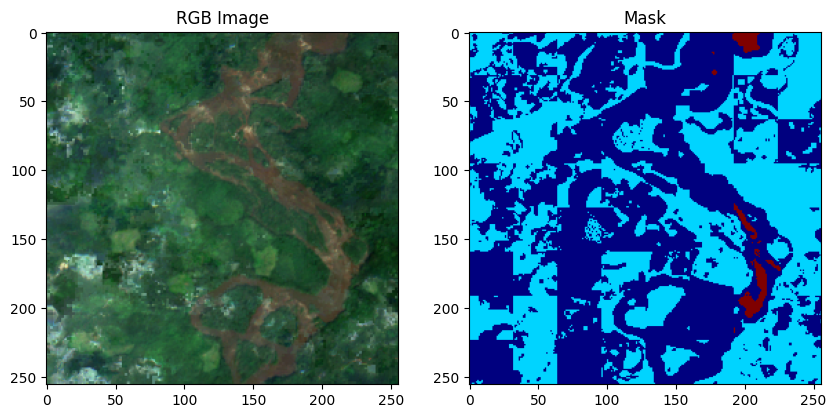

In [ ]:
import rasterio
import matplotlib.pyplot as plt

img_path = "data/imgs/img_32.tif"
mask_path = "data/masks/mask_32.tif"

with rasterio.open(img_path) as src:
    img = src.read()

rgb = img[[3, 2, 1]]  
rgb = rgb.transpose(1, 2, 0)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("RGB Image")
plt.imshow(rgb)

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask, cmap='jet')

plt.show()